Dataset shape: (331442, 11)
Success rate: 40.4%


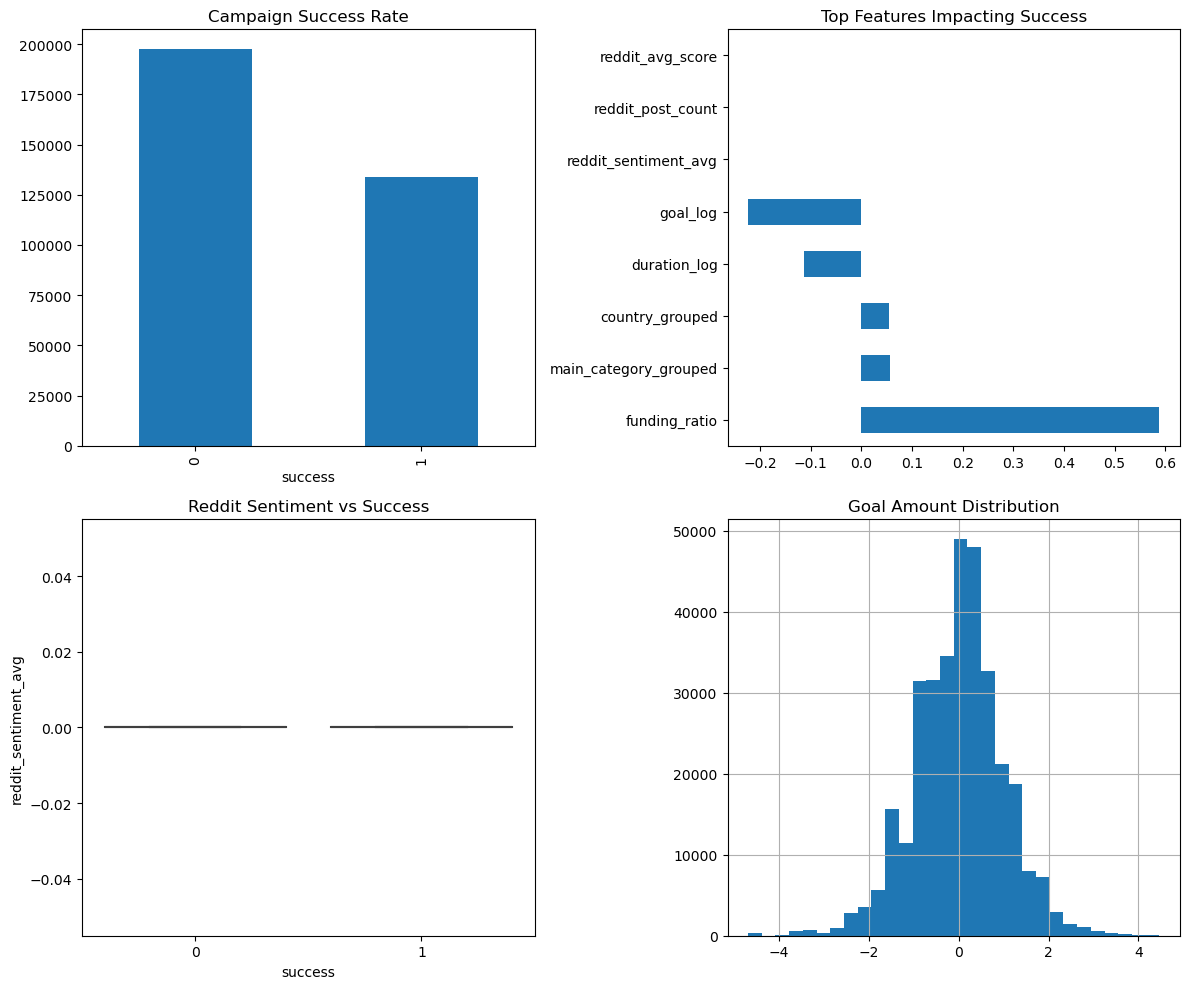

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


df = pd.read_csv('data/integrated/final_training_data.csv')
print(f"Dataset shape: {df.shape}")
print(f"Success rate: {df['success'].mean():.1%}")


fig, axes = plt.subplots(2, 2, figsize=(12, 10))


df['success'].value_counts().plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title('Campaign Success Rate')


corr = df.corr()['success'].sort_values(ascending=False)
corr.drop('success').head(8).plot(kind='barh', ax=axes[0,1])
axes[0,1].set_title('Top Features Impacting Success')


if 'reddit_sentiment_avg' in df.columns:
    sns.boxplot(data=df, x='success', y='reddit_sentiment_avg', ax=axes[1,0])
    axes[1,0].set_title('Reddit Sentiment vs Success')

df.iloc[:,0].hist(bins=30, ax=axes[1,1])  
axes[1,1].set_title('Goal Amount Distribution')

plt.tight_layout()
plt.savefig('review_demo.png', dpi=300, bbox_inches='tight')
plt.show()
